In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/listings.csv.gz")
df["price"] = (
    df["price"].str.replace("$", "", regex=False)
               .str.replace(",", "", regex=False)
               .astype(float)
)
print("Lignes :", len(df))
print("Prix manquants :", df["price"].isna().sum())
print(df["price"].describe(percentiles=[.01, .5, .95, .99]))

Lignes : 77679
Prix manquants : 29277
count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
1%          29.870000
50%        205.500000
95%        842.392500
99%       1874.980000
max      97003.050000
Name: price, dtype: float64


In [2]:
cols = ["neighbourhood_cleansed", "room_type", "property_type",
        "bedrooms", "beds", "accommodates", "bathrooms",
        "number_of_reviews", "review_scores_rating",
        "availability_365", "minimum_nights",
        "latitude", "longitude", "price"]
print(df[cols].isna().mean().sort_values(ascending=False).round(3))
print(df["room_type"].value_counts())
print(df["neighbourhood_cleansed"].nunique(), "quartiers")

bathrooms                 0.417
beds                      0.397
price                     0.377
review_scores_rating      0.205
bedrooms                  0.180
room_type                 0.000
accommodates              0.000
property_type             0.000
neighbourhood_cleansed    0.000
number_of_reviews         0.000
availability_365          0.000
minimum_nights            0.000
latitude                  0.000
longitude                 0.000
dtype: float64
room_type
Entire home/apt    69265
Private room        7858
Hotel room           410
Shared room          146
Name: count, dtype: int64
20 quartiers


In [3]:
d = df.dropna(subset=["price"]).copy()
print("Lignes avec prix :", len(d))
print(d[cols].isna().mean().sort_values(ascending=False).round(3).head(5))

for lo, hi in [(20, 500), (20, 1000), (20, 2000)]:
    n = d["price"].between(lo, hi).sum()
    print(f"{lo}-{hi} : {n} lignes ({n / len(d):.1%})")

print(d["minimum_nights"].describe(percentiles=[.5, .95, .99]))

Lignes avec prix : 48402
review_scores_rating    0.172
bedrooms                0.160
bathrooms               0.121
beds                    0.090
room_type               0.000
dtype: float64
20-500 : 41758 lignes (86.3%)
20-1000 : 46392 lignes (95.8%)
20-2000 : 47631 lignes (98.4%)
count    48402.000000
mean         8.199207
std         26.841987
min          1.000000
50%          2.000000
95%         30.000000
99%         60.000000
max        365.000000
Name: minimum_nights, dtype: float64


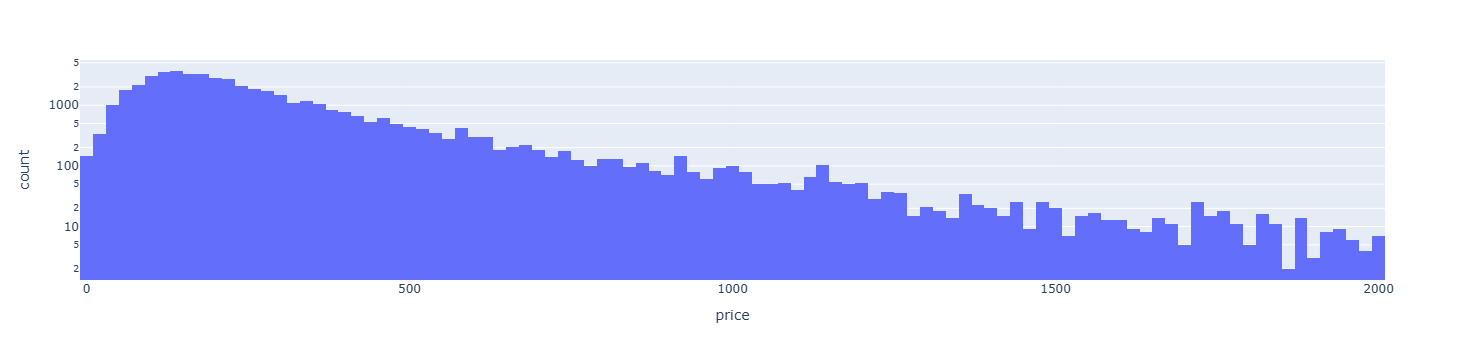

In [4]:
import plotly.express as px
px.histogram(d[d["price"] <= 2000], x="price", nbins=100, log_y=True).show()

In [5]:
f = d[d["price"].between(20, 1000) & (d["minimum_nights"] <= 30)].copy()
print("Lignes après filtres :", len(f), f"({len(f)/len(d):.1%})")

# Notes manquantes = logements sans avis ?
print("Note manquante ET 0 avis :", (f["review_scores_rating"].isna() & (f["number_of_reviews"] == 0)).sum())
print("Note manquante au total  :", f["review_scores_rating"].isna().sum())

# Chambres manquantes : quels logements ?
print(f.loc[f["bedrooms"].isna(), "room_type"].value_counts())
print(f.groupby("room_type")["bedrooms"].median())
print(f.groupby("accommodates")["bedrooms"].median().head(8))

Lignes après filtres : 45973 (95.0%)
Note manquante ET 0 avis : 7360
Note manquante au total  : 7360
room_type
Entire home/apt    4828
Private room       2594
Shared room          52
Hotel room           34
Name: count, dtype: int64
room_type
Entire home/apt    1.0
Hotel room         1.0
Private room       1.0
Shared room        1.0
Name: bedrooms, dtype: float64
accommodates
1    1.0
2    1.0
3    1.0
4    1.0
5    2.0
6    2.0
7    3.0
8    3.0
Name: bedrooms, dtype: float64
